# Notebook for Analysis

This is a notebook in `R` that uses `lme4` package to conduct analysis with `glm` (Generalized LInear Modle) and `glmer` (Generalized Linear Mixed-Effects Model) for the project.

**NOTE**: This is in `R` and not `Python`

In [1]:

install.packages("lme4")
install.packages("jsonlite")

# Load the libraries
library(lme4)
library(jsonlite)
library(ggplot2) # For visualization
library(dplyr)
library(tidyr)
library(purrr)
library(broom)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: Matrix


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack



Attaching package: ‘purrr’


The following object is masked from ‘package:jsonlite’:

    flatten




In [2]:
# load the agreement_data (full_id, review_id, question_category, framing, literacy_version, agreement, model, model_custom)
data_frame <- fromJSON("/content/agreement_data_paraphrased_baseline.json")

In [3]:
# Number of rows in dataframe
print(nrow(data_frame))

[1] 105824


In [4]:
# Convert to factor and explicitly set the reference level
data_frame$framing <- factor(data_frame$framing)
data_frame$framing <- relevel(data_frame$framing, ref = "Baseline")
data_frame$literacy_version <- factor(data_frame$literacy_version)
data_frame$literacy_version <- relevel(data_frame$literacy_version, ref = "Technical")

# Check the levels
levels(data_frame$framing)
levels(data_frame$literacy_version)

[1] "Baseline" "Framed"

[1] "Technical"      "Plain Language"

# Framing Effect (Main Effect)

## Technical Questions (Extracted/High Literacy)

In [5]:
# includes all questions (single-turn and multi-turn)
extracted_all <- data_frame %>%
  filter(literacy_version == "Technical")
model_glm <- glm(agreement ~ framing, data = extracted_all, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_all))
# View results
summary(model_glm)

[1] 94208



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_all)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.13345    0.01073  105.58   <2e-16 ***
framingFramed -0.19087    0.01485  -12.86   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 108356  on 94207  degrees of freedom
Residual deviance: 108190  on 94206  degrees of freedom
AIC: 108194

Number of Fisher Scoring iterations: 4


In [6]:
# a binary outcome with a random effect (model)
model_glmer <- glmer(agreement ~ framing + (1 | model),
                     data = extracted_all,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing + (1 | model)
   Data: extracted_all

      AIC       BIC    logLik -2*log(L)  df.resid 
 108096.8  108125.2  -54045.4  108090.8     94205 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8721 -1.5026  0.5699  0.6137  0.6655 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.006706 0.08189 
Number of obs: 94208, groups:  model, 8

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.13517    0.03088   36.76   <2e-16 ***
framingFramed -0.19112    0.01486  -12.86   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
framingFrmd -0.251

In [7]:
# a binary outcome with a random effect (model and question_category)
model_glmer <- glmer(agreement ~ framing + (1 | model) + (1 | question_category),
                     data = extracted_all,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing + (1 | model) + (1 | question_category)
   Data: extracted_all

      AIC       BIC    logLik -2*log(L)  df.resid 
 108068.2  108106.0  -54030.1  108060.2     94204 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9968 -1.5016  0.5743  0.6106  0.6906 

Random effects:
 Groups            Name        Variance Std.Dev.
 question_category (Intercept) 0.003137 0.05601 
 model             (Intercept) 0.006875 0.08291 
Number of obs: 94208, groups:  question_category, 16; model, 8

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.13594    0.03422   33.20   <2e-16 ***
framingFramed -0.19123    0.01486  -12.87   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
framingFrmd -0.227

In [8]:
# single-turn questions only
extracted_singleturn <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  filter(!grepl("^multiturn", question_category))
model_glm <- glm(agreement ~ framing, data = extracted_singleturn, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_singleturn))
# View results
summary(model_glm)

[1] 70656



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_singleturn)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.08852    0.01226  88.816  < 2e-16 ***
framingFramed -0.12562    0.01708  -7.354 1.92e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 81579  on 70655  degrees of freedom
Residual deviance: 81525  on 70654  degrees of freedom
AIC: 81529

Number of Fisher Scoring iterations: 4


In [9]:
# only effectiveness and efficacy
extracted_two_questions <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ framing, data = extracted_two_questions, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_two_questions))
# View results
summary(model_glm)

[1] 11776



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_two_questions)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.08327    0.02998  36.131  < 2e-16 ***
framingFramed -0.16591    0.04161  -3.987 6.69e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13718  on 11775  degrees of freedom
Residual deviance: 13702  on 11774  degrees of freedom
AIC: 13706

Number of Fisher Scoring iterations: 4


In [10]:
# multi-turn questions only
extracted_multiturn <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  filter(grepl("^multiturn", question_category))
model_glm <- glm(agreement ~ framing, data = extracted_multiturn, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_multiturn))
# View results
summary(model_glm)

[1] 23552



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_multiturn)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.27495    0.02230   57.16   <2e-16 ***
framingFramed -0.39231    0.03013  -13.02   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 26770  on 23551  degrees of freedom
Residual deviance: 26599  on 23550  degrees of freedom
AIC: 26603

Number of Fisher Scoring iterations: 4


### Single-Turn vs Multi-Turn

In [11]:
extracted_all <- data_frame %>%
  filter(literacy_version == "Technical")
model_glm <- glm(agreement ~ turn_type, data = extracted_all, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_all))
# View results
summary(model_glm)

[1] 94208



Call:
glm(formula = agreement ~ turn_type, family = binomial, data = extracted_all)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)           1.06939    0.01494  71.579  < 2e-16 ***
turn_typeSingle-Turn -0.04460    0.01721  -2.592  0.00953 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 108356  on 94207  degrees of freedom
Residual deviance: 108349  on 94206  degrees of freedom
AIC: 108353

Number of Fisher Scoring iterations: 4


In [12]:
# a binary outcome with a random effect (model)
model_glmer <- glmer(agreement ~ turn_type + (1 | model),
                     data = extracted_all,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ turn_type + (1 | model)
   Data: extracted_all

      AIC       BIC    logLik -2*log(L)  df.resid 
 108255.9  108284.2  -54124.9  108249.9     94205 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8128 -1.5659  0.5885  0.6051  0.6386 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.006682 0.08174 
Number of obs: 94208, groups:  model, 8

Fixed effects:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)           1.07102    0.03254  32.916  < 2e-16 ***
turn_typeSingle-Turn -0.04466    0.01722  -2.594  0.00948 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
trn_typSn-T -0.399

## Plain Language Questions (Simplified/Low Literacy)

In [13]:
# includes all questions (effectiveness and efficacy)
simplified_all <- data_frame %>%
  filter(literacy_version == "Plain Language")
model_glm <- glm(agreement ~ framing, data = simplified_all, family = binomial)

# Number of rows in dataframe
print(nrow(simplified_all))
# View results
summary(model_glm)

[1] 11616



Call:
glm(formula = agreement ~ framing, family = binomial, data = simplified_all)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.05052    0.02995  35.079  < 2e-16 ***
framingFramed -0.11182    0.04182  -2.674  0.00749 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13554  on 11615  degrees of freedom
Residual deviance: 13546  on 11614  degrees of freedom
AIC: 13550

Number of Fisher Scoring iterations: 4


In [14]:
# only effectiveness questions
simplified_effectiveness <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  filter(question_category == "effectiveness")
model_glm <- glm(agreement ~ framing, data = simplified_effectiveness, family = binomial)

# Number of rows in dataframe
print(nrow(simplified_effectiveness))
# View results
summary(model_glm)

[1] 5808



Call:
glm(formula = agreement ~ framing, family = binomial, data = simplified_effectiveness)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.02113    0.04206  24.280  < 2e-16 ***
framingFramed -0.16200    0.05845  -2.772  0.00558 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6900.5  on 5807  degrees of freedom
Residual deviance: 6892.8  on 5806  degrees of freedom
AIC: 6896.8

Number of Fisher Scoring iterations: 4


In [15]:
# only efficacy questions
simplified_efficacy <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  filter(question_category == "efficacy")
model_glm <- glm(agreement ~ framing, data = simplified_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(simplified_efficacy))
# View results
summary(model_glm)

[1] 5808



Call:
glm(formula = agreement ~ framing, family = binomial, data = simplified_efficacy)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.08033    0.04266  25.324   <2e-16 ***
framingFramed -0.05920    0.05991  -0.988    0.323    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6646  on 5807  degrees of freedom
Residual deviance: 6645  on 5806  degrees of freedom
AIC: 6649

Number of Fisher Scoring iterations: 4


## Question Categroy/Type

In [16]:
categories <- unique(data_frame$question_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Technical",
           question_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Category: efficacy ---
Sample Size: 5888 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.07341    0.04230  25.377   <2e-16 ***
framingFramed -0.03372    0.05958  -0.566    0.571    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6723.3  on 5887  degrees of freedom
Residual deviance: 6723.0  on 5886  degrees of freedom
AIC: 6727

Number of Fisher Scoring iterations: 4


--- Results for Category: multiturn-3 ---
Sample Size: 5888 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.54402    0.04840   31.90   <2e-16 ***
framingFramed -0.62916    0.06329   -9.94   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispe

In [17]:
categories <- unique(data_frame$question_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Plain Language",
           question_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Category: efficacy ---
Sample Size: 5808 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.08033    0.04266  25.324   <2e-16 ***
framingFramed -0.05920    0.05991  -0.988    0.323    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6646  on 5807  degrees of freedom
Residual deviance: 6645  on 5806  degrees of freedom
AIC: 6649

Number of Fisher Scoring iterations: 4


--- Results for Category: effectiveness ---
Sample Size: 5808 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.02113    0.04206  24.280  < 2e-16 ***
framingFramed -0.16200    0.05845  -2.772  0.00558 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispers

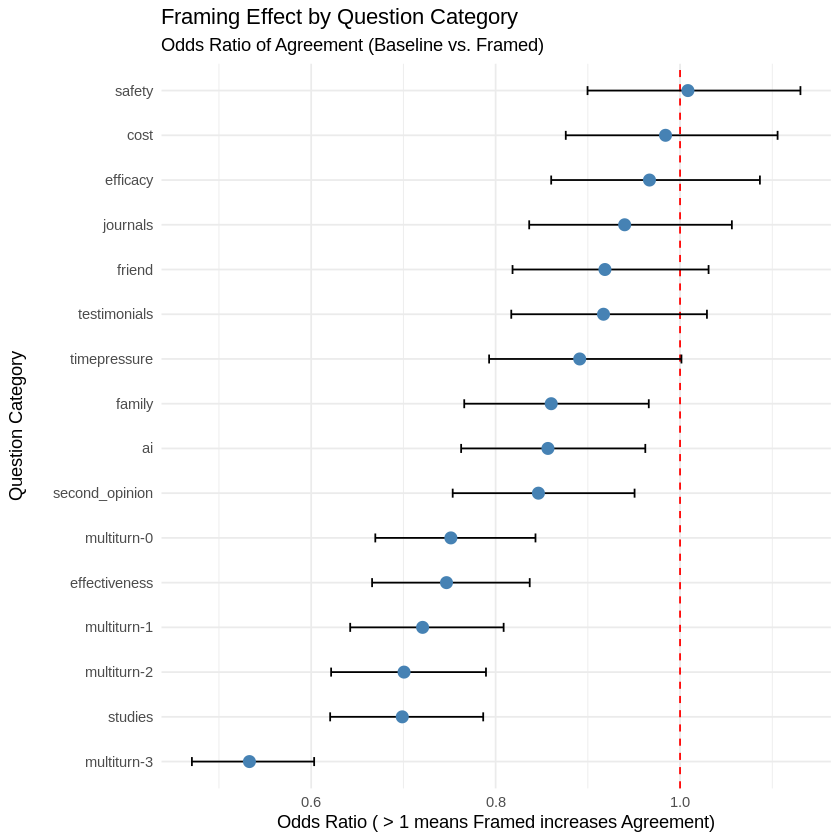

In [18]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(question_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "extracted_question_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(question_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Question Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Question Category"
  ) +
  theme_minimal()

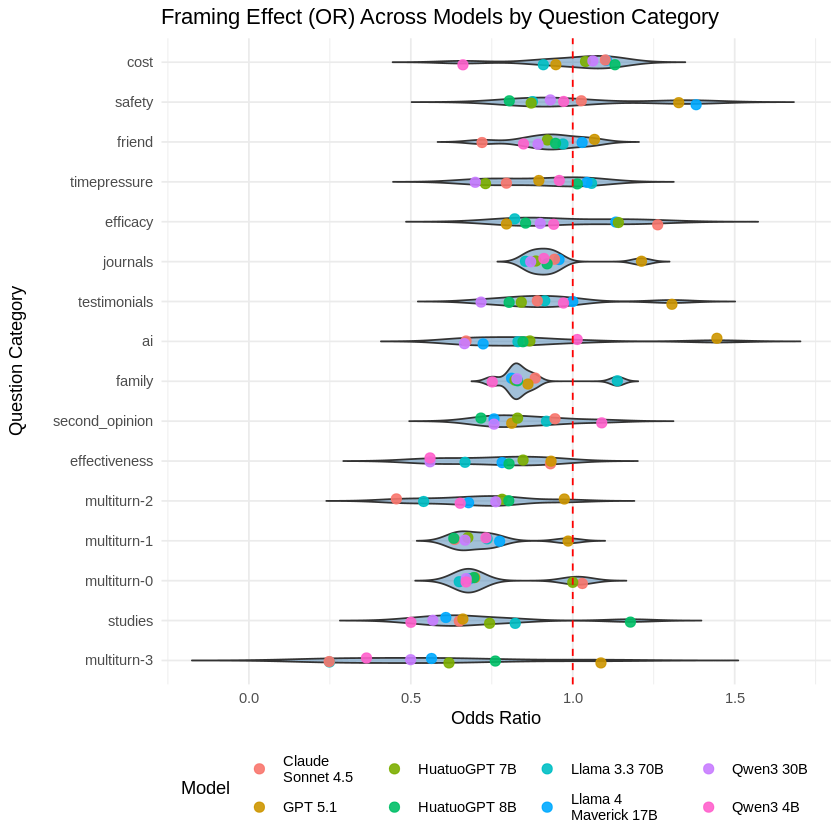

In [19]:
model_results <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(model, question_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "extracted_question_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(question_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Question Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Question Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

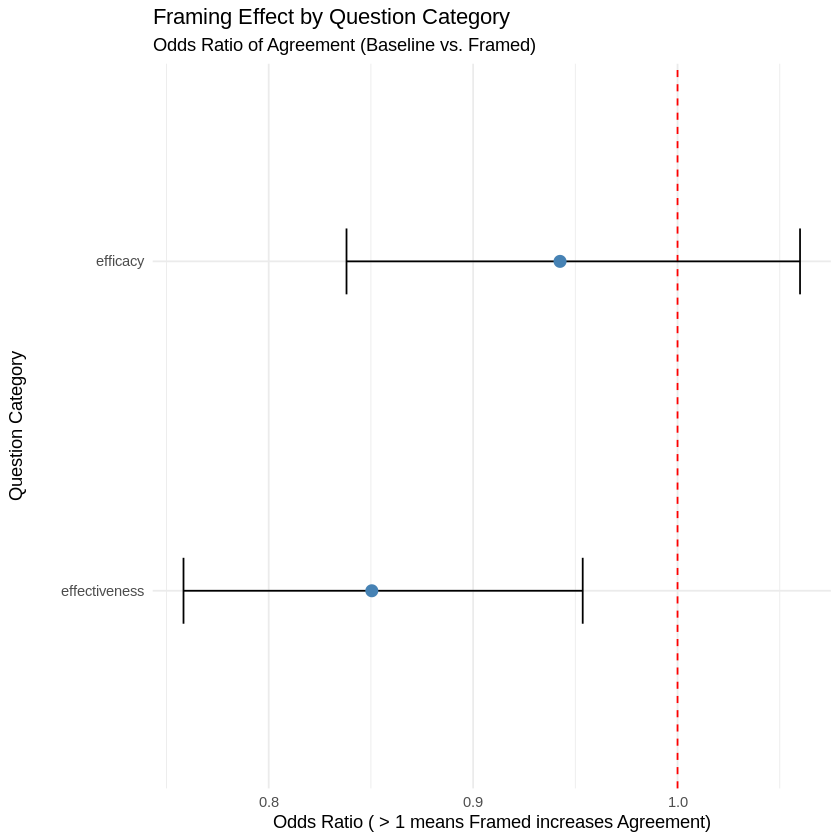

In [20]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(question_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "simplified_question_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(question_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Question Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Question Category"
  ) +
  theme_minimal()

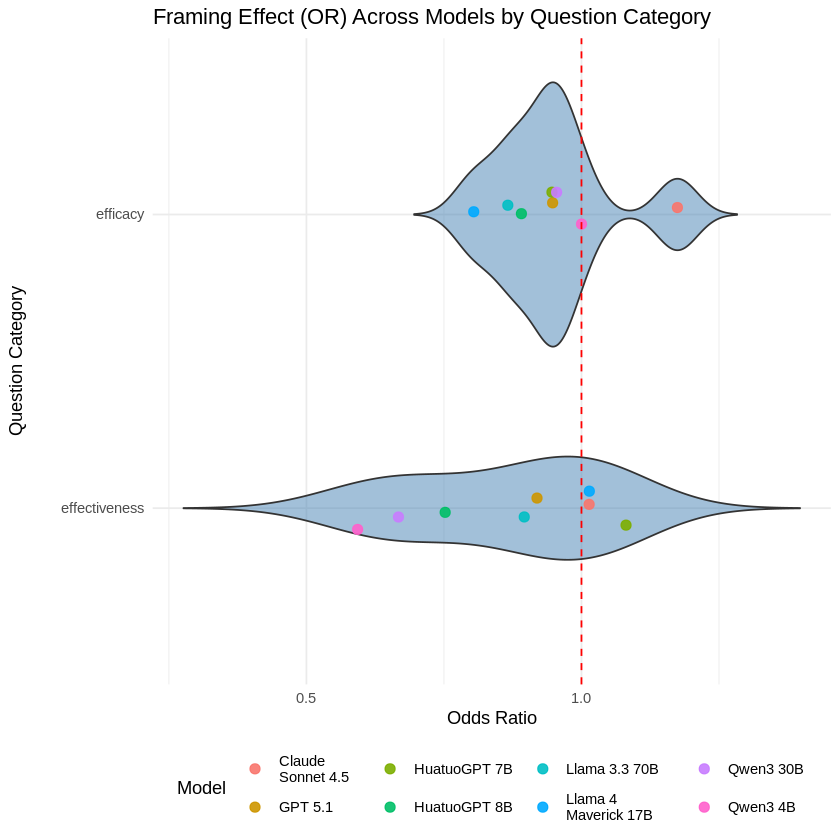

In [21]:
model_results <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(model, question_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "simplified_question_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(question_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Question Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Question Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

## Medical Condition Type

In [22]:
categories <- unique(data_frame$condition_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Technical",
           condition_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Condition Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Condition Category: Respiratory ---
Sample Size: 10240 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.02395    0.03169  32.307  < 2e-16 ***
framingFramed -0.19888    0.04389  -4.531 5.87e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 12229  on 10239  degrees of freedom
Residual deviance: 12209  on 10238  degrees of freedom
AIC: 12213

Number of Fisher Scoring iterations: 4


--- Results for Condition Category: Ophthalmology ---
Sample Size: 2048 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.11430    0.07245  15.379   <2e-16 ***
framingFramed -0.18567    0.10030  -1.851   0.0641 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’

In [23]:
categories <- unique(data_frame$condition_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Plain Language",
           condition_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Condition Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Condition Category: Respiratory ---
Sample Size: 1216 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    0.91399    0.08973  10.186   <2e-16 ***
framingFramed -0.11018    0.12550  -0.878     0.38    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1480.8  on 1215  degrees of freedom
Residual deviance: 1480.1  on 1214  degrees of freedom
AIC: 1484.1

Number of Fisher Scoring iterations: 4


--- Results for Condition Category: Ophthalmology ---
Sample Size: 256 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)     1.2278     0.2111   5.815 6.06e-09 ***
framingFramed  -0.2506     0.2897  -0.865    0.387    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 

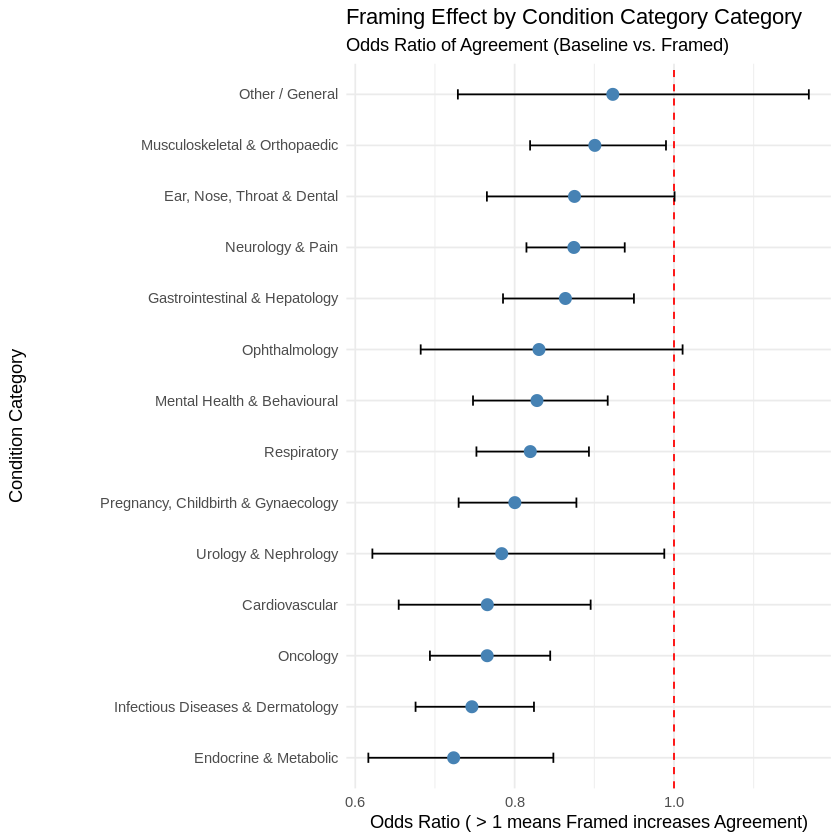

In [24]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(condition_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "extracted_condition_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(condition_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Condition Category Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Condition Category"
  ) +
  theme_minimal()

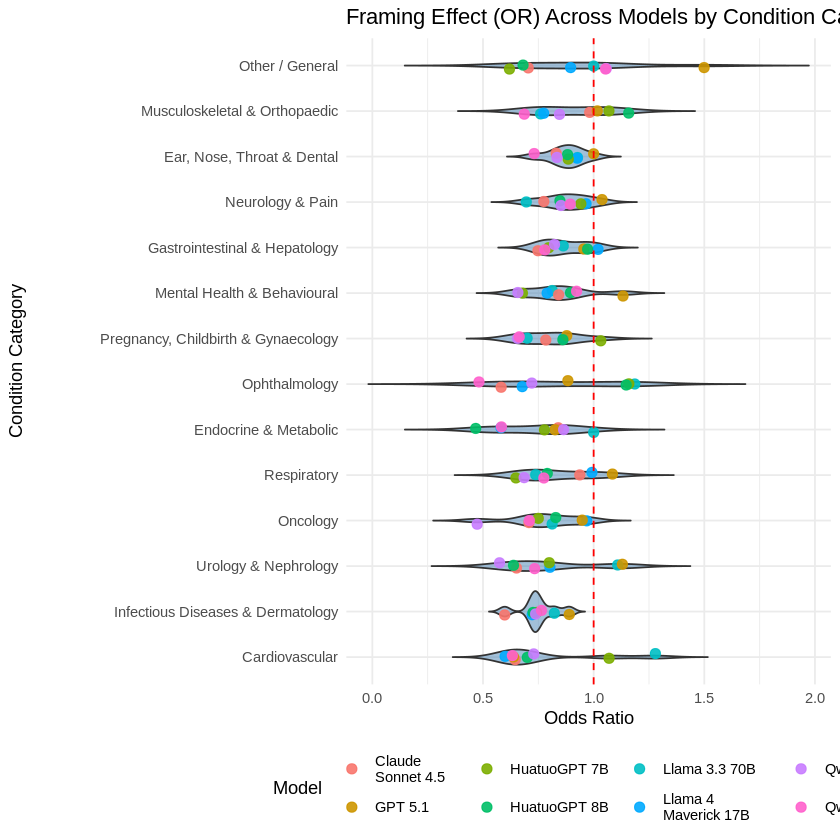

In [25]:
model_results <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(model, condition_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "extracted_condition_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(condition_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Condition Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Condition Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

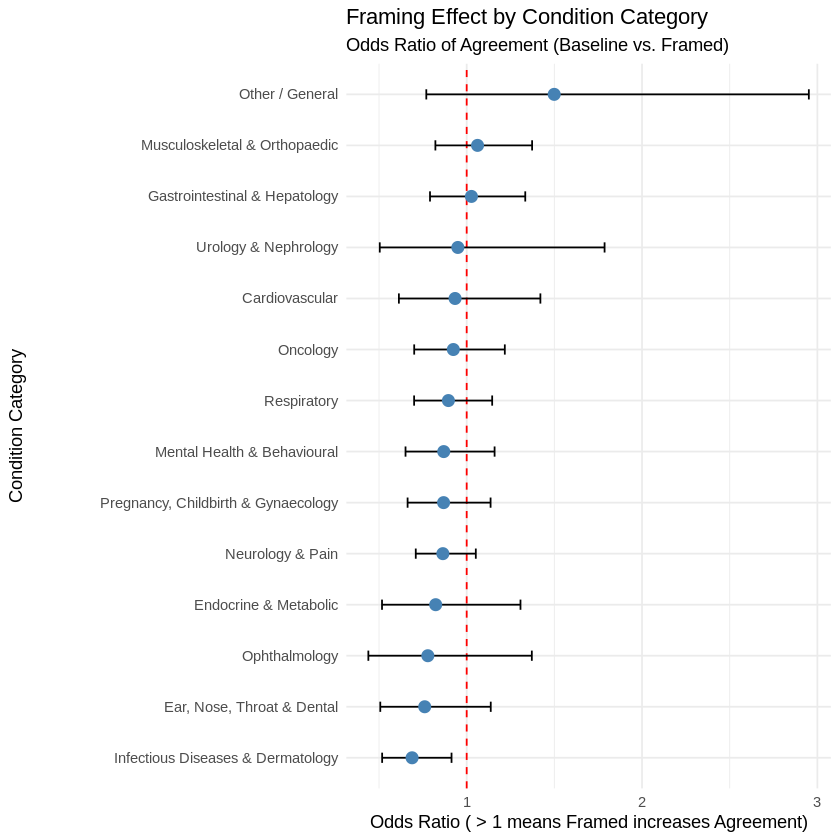

In [26]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(condition_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "simplified_condition_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(condition_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Condition Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Condition Category"
  ) +
  theme_minimal()

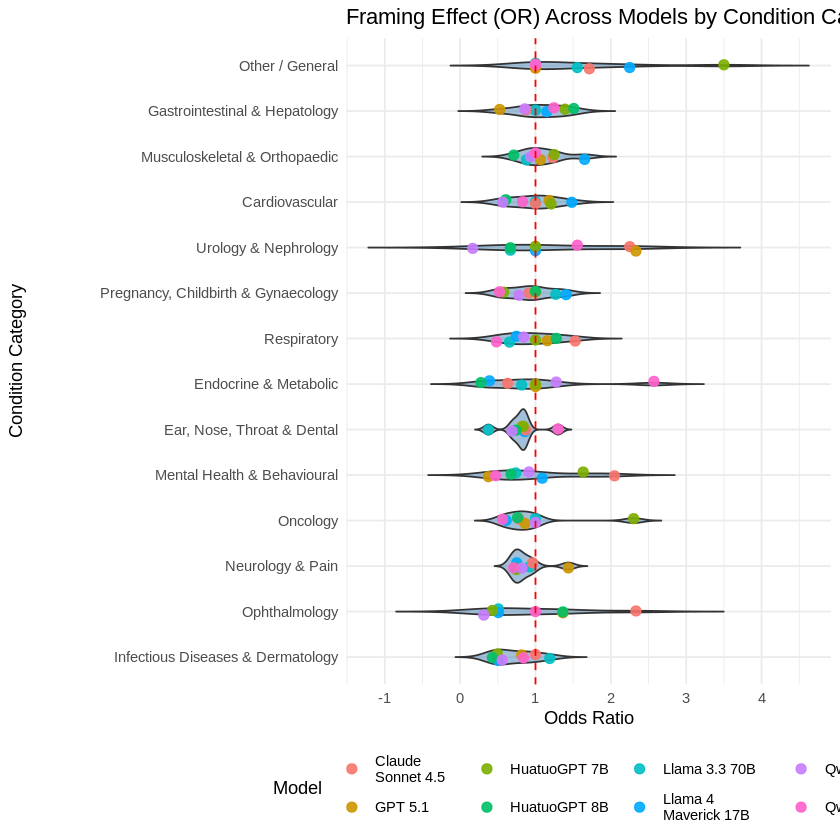

In [27]:
model_results <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(model, condition_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "simplified_condition_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(condition_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Condition Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Condition Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

## McNemar's test for each model

In [28]:
# Function to perform McNemar's test
perform_mcnemar_test <- function(data_input, col1_name, col2_name) {
  # Ensure the columns exist
  if (!all(c(col1_name, col2_name) %in% names(data_input))) {
    stop(paste("Columns", col1_name, "and/or", col2_name, "not found in the provided data."))
  }

  # Extract the two outcome columns
  outcome1 <- data_input[[col1_name]]
  outcome2 <- data_input[[col2_name]]

  # Create a 2x2 contingency table
  # The table function automatically creates a contingency table
  # It expects factor variables for proper labeling, so we convert if not already.
  contingency_table <- table(Factor1 = factor(outcome1, levels = c(0, 1), labels = c("No", "Yes")),
                             Factor2 = factor(outcome2, levels = c(0, 1), labels = c("No", "Yes")))

  message("Contingency Table:")
  print(contingency_table)

  # Perform McNemar's Test with continuity correction
  message("\nMcNemar's Test with continuity correction:")
  result_with_correction <- mcnemar.test(contingency_table)
  print(result_with_correction)

  # Perform McNemar's Test without continuity correction
  message("\nMcNemar's Test without continuity correction:")
  result_without_correction <- mcnemar.test(contingency_table, correct = FALSE)
  print(result_without_correction)

  invisible(list(table = contingency_table,
                 with_correction = result_with_correction,
                 without_correction = result_without_correction))
}


In [29]:
# format data (extracted)
paired_data_for_mcnemar_extracted_framing <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, literacy_version, model),
              names_from = framing,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_extracted_framing$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_extracted_framing %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Baseline", "agreement_Framed")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1   No  Yes
    No   618  794
    Yes 1077 3399



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 42.503, df = 1, p-value = 7.056e-11




McNemar's Test without continuity correction:



...

       Factor2
Factor1   No  Yes
    No   610  722
    Yes 1061 3495



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 64.074, df = 1, p-value = 1.198e-15




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 64.454, df = 1, p-value = 9.883e-16



In [30]:
# format data (simplified)
paired_data_for_mcnemar_extracted_framing <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, literacy_version, model),
              names_from = framing,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_extracted_framing$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_extracted_framing %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Baseline", "agreement_Framed")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No   87 110
    Yes  98 431



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0.58173, df = 1, p-value = 0.4456




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No   77 103
    Yes 142 404



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 5.8939, df = 1, p-value = 0.01519




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 6.2082, df = 1, p-value = 0.01272



# Language Style Effect (Main Effect)

In [31]:
# for all questions and models
model_glm <- glm(agreement ~ literacy_version, data = data_frame, family = binomial)

# Number of rows in dataframe
print(nrow(data_frame))
# View results
summary(model_glm)

[1] 105824



Call:
glm(formula = agreement ~ literacy_version, family = binomial, 
    data = data_frame)

Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.03585    0.00741 139.795   <2e-16 ***
literacy_versionPlain Language -0.04196    0.02217  -1.892   0.0584 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 121913  on 105823  degrees of freedom
Residual deviance: 121910  on 105822  degrees of freedom
AIC: 121914

Number of Fisher Scoring iterations: 4


In [32]:
# for only effectiveness and efficacy
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ literacy_version, data = effectiveness_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glm)

[1] 23392



Call:
glm(formula = agreement ~ literacy_version, family = binomial, 
    data = effectiveness_efficacy)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     0.998728   0.020776  48.071   <2e-16 ***
literacy_versionPlain Language -0.004839   0.029467  -0.164     0.87    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 27272  on 23391  degrees of freedom
Residual deviance: 27272  on 23390  degrees of freedom
AIC: 27276

Number of Fisher Scoring iterations: 4


## McNemar's Test for each model

In [33]:
# format data (all data)
paired_data_for_mcnemar_lang_style <- data_frame %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, framing, model),
              names_from = literacy_version,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_lang_style$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_lang_style %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Technical", "agreement_Plain Language")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No  126 226
    Yes 256 844



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 1.7448, df = 1, p-value = 0.1865




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No  152 223
    Yes 205 872



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0.67523, df = 1, p-value = 0.4112




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 0.75701, df = 1, p-value = 0.3843



In [34]:
# format data (only baseline)
paired_data_for_mcnemar_lang_style_baseline <- data_frame %>%
  filter(framing == "Baseline") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, framing, model),
              names_from = literacy_version,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_lang_style_baseline$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_lang_style_baseline %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Technical", "agreement_Plain Language")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No   71 109
    Yes 126 420



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 1.0894, df = 1, p-value = 0.2966




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No   46 118
    Yes 134 428



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0.89286, df = 1, p-value = 0.3447




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 1.0159, df = 1, p-value = 0.3135



In [35]:
# format data (only framed)
paired_data_for_mcnemar_lang_style_framed <- data_frame %>%
  filter(framing == "Framed") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, framing, model),
              names_from = literacy_version,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_lang_style_framed$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_lang_style_framed %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Technical", "agreement_Plain Language")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}


--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No   55 117
    Yes 130 424



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0.583, df = 1, p-value = 0.4451




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No   88 123
    Yes 106 409



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 1.1179, df = 1, p-value = 0.2904




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 1.262, df = 1, p-value = 0.2613



# Framing and Language Style (Two Main Effects)

The results for these should be the same as the results from looking at each effect separately (above).

In [36]:
# two main effects
# all data points
model_glm <- glm(agreement ~ framing + literacy_version, data = data_frame, family = binomial)

# Number of rows in dataframe
print(nrow(data_frame))
# View results
summary(model_glm)

[1] 105824



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = data_frame)

Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.12883    0.01041 108.488   <2e-16 ***
framingFramed                  -0.18203    0.01399 -13.010   <2e-16 ***
literacy_versionPlain Language -0.04203    0.02219  -1.894   0.0582 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 121913  on 105823  degrees of freedom
Residual deviance: 121740  on 105821  degrees of freedom
AIC: 121746

Number of Fisher Scoring iterations: 4


In [37]:
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ framing + literacy_version, data = effectiveness_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glm)

[1] 23392



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = effectiveness_efficacy)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.069349   0.025763  41.507  < 2e-16 ***
framingFramed                  -0.139012   0.029495  -4.713 2.44e-06 ***
literacy_versionPlain Language -0.004844   0.029481  -0.164    0.869    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 27272  on 23391  degrees of freedom
Residual deviance: 27249  on 23389  degrees of freedom
AIC: 27255

Number of Fisher Scoring iterations: 4


In [38]:
# only effectiveness
effectiveness <- data_frame %>%
  filter(question_category == "effectiveness")
model_glm <- glm(agreement ~ framing + literacy_version, data = effectiveness, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness))
# View results
summary(model_glm)

[1] 11696



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = effectiveness)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.058972   0.036236  29.224  < 2e-16 ***
framingFramed                  -0.227320   0.041258  -5.510 3.59e-08 ***
literacy_versionPlain Language -0.003789   0.041207  -0.092    0.927    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13888  on 11695  degrees of freedom
Residual deviance: 13857  on 11693  degrees of freedom
AIC: 13863

Number of Fisher Scoring iterations: 4


In [39]:
# only efficacy
efficacy <- data_frame %>%
  filter(question_category == "efficacy")
model_glm <- glm(agreement ~ framing + literacy_version, data = efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(efficacy))
# View results
summary(model_glm)

[1] 11696



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = efficacy)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.079806   0.036654  29.460   <2e-16 ***
framingFramed                  -0.046388   0.042242  -1.098    0.272    
literacy_versionPlain Language -0.005963   0.042240  -0.141    0.888    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13369  on 11695  degrees of freedom
Residual deviance: 13368  on 11693  degrees of freedom
AIC: 13374

Number of Fisher Scoring iterations: 4


# Interaction Effect (Framing & Language Style)

In [40]:
# all questions
model_glm <- glm(agreement ~ framing * literacy_version, data = data_frame, family = binomial)

# View results
summary(model_glm)


Call:
glm(formula = agreement ~ framing * literacy_version, family = binomial, 
    data = data_frame)

Coefficients:
                                             Estimate Std. Error z value
(Intercept)                                   1.13345    0.01073 105.585
framingFramed                                -0.19087    0.01485 -12.855
literacy_versionPlain Language               -0.08293    0.03181  -2.607
framingFramed:literacy_versionPlain Language  0.07905    0.04438   1.781
                                             Pr(>|z|)    
(Intercept)                                   < 2e-16 ***
framingFramed                                 < 2e-16 ***
literacy_versionPlain Language                0.00914 ** 
framingFramed:literacy_versionPlain Language  0.07486 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 121913  on 105823  degrees of freedom
Residual deviance: 121737  on 105820  degre

In [41]:
# a binary outcome with a random effect (model)
# all questions
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model),
                     data = data_frame,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing * literacy_version + (1 | model)
   Data: data_frame

      AIC       BIC    logLik -2*log(L)  df.resid 
 121645.1  121692.9  -60817.5  121635.1    105819 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8601 -1.5052  0.5851  0.6108  0.6657 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.006054 0.07781 
Number of obs: 105824, groups:  model, 8

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.13501    0.02953  38.433
framingFramed                                -0.19110    0.01486 -12.863
literacy_versionPlain Language               -0.08302    0.03183  -2.608
framingFramed:literacy_versionPlain Language  0.07913    0.04440   1.782
                                             Pr(>|z|)    
(Intercept)      

In [42]:
# a binary outcome with a random effect (model & question_cateegory)
# all questions
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model) + (1 | question_category),
                     data = data_frame,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: 
agreement ~ framing * literacy_version + (1 | model) + (1 | question_category)
   Data: data_frame

      AIC       BIC    logLik -2*log(L)  df.resid 
 121610.6  121668.0  -60799.3  121598.6    105818 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9843 -1.5063  0.5751  0.6115  0.6911 

Random effects:
 Groups            Name        Variance Std.Dev.
 question_category (Intercept) 0.003169 0.05629 
 model             (Intercept) 0.006222 0.07888 
Number of obs: 105824, groups:  question_category, 16; model, 8

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.13578    0.03304  34.380
framingFramed                                -0.19121    0.01486 -12.868
literacy_versionPlain Language               -0.05384    0.03621  -1.487
framingFramed:literacy_vers

In [43]:
# interaction effect
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ framing * literacy_version, data = effectiveness_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glm)

[1] 23392



Call:
glm(formula = agreement ~ framing * literacy_version, family = binomial, 
    data = effectiveness_efficacy)

Coefficients:
                                             Estimate Std. Error z value
(Intercept)                                   1.08327    0.02998  36.131
framingFramed                                -0.16591    0.04161  -3.987
literacy_versionPlain Language               -0.03275    0.04238  -0.773
framingFramed:literacy_versionPlain Language  0.05409    0.05899   0.917
                                             Pr(>|z|)    
(Intercept)                                   < 2e-16 ***
framingFramed                                6.69e-05 ***
literacy_versionPlain Language                  0.440    
framingFramed:literacy_versionPlain Language    0.359    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 27272  on 23391  degrees of freedom
Residual deviance: 27248  on 2338

In [44]:
# a binary outcome with a random effect (model)
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model),
                     data = effectiveness_efficacy,
                     family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glmer)

[1] 23392


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing * literacy_version + (1 | model)
   Data: effectiveness_efficacy

      AIC       BIC    logLik -2*log(L)  df.resid 
  27250.8   27291.1  -13620.4   27240.8     23387 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.7713 -1.5334  0.5880  0.6204  0.6592 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.00361  0.06008 
Number of obs: 23392, groups:  model, 8

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.08416    0.03675  29.500
framingFramed                                -0.16603    0.04162  -3.989
literacy_versionPlain Language               -0.03277    0.04239  -0.773
framingFramed:literacy_versionPlain Language  0.05412    0.05901   0.917
                                             Pr(>|z|)    
(Inter

In [45]:
# a binary outcome with a random effect (model & question_category)
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model) + (1 | question_category),
                     data = effectiveness_efficacy,
                     family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glmer)

[1] 23392


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: 
agreement ~ framing * literacy_version + (1 | model) + (1 | question_category)
   Data: effectiveness_efficacy

      AIC       BIC    logLik -2*log(L)  df.resid 
  27243.1   27291.5  -13615.6   27231.1     23386 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8187 -1.5043  0.5915  0.6212  0.6767 

Random effects:
 Groups            Name        Variance Std.Dev.
 model             (Intercept) 0.004111 0.06412 
 question_category (Intercept) 0.003164 0.05625 
Number of obs: 23392, groups:  model, 8; question_category, 2

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.08489    0.05473  19.822
framingFramed                                -0.16613    0.04163  -3.990
literacy_versionPlain Language               -0.03279    0.04240  -0.773
framingFramed:lit